### Parallel workflow

check the tablet docs before checking the code

In [40]:
from langgraph.graph import StateGraph, START, END 
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import Field, BaseModel
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

In [41]:
load_dotenv()

True

In [42]:
# create the model
# llm = HuggingFaceEndpoint(
#     repo_id="google/gemma-2-2b-it",
#     task="text-generation"
# )

# model = ChatHuggingFace(llm=llm)

# model = ChatOpenAI()
model = ChatGoogleGenerativeAI(model="gemini-3.6-flash", temperature=0)

In [43]:
# Used for structured output from schema 
class EvaluateSchema(BaseModel):
    feedback: str = Field(description="A detailed feedback about the essay")
    score: int = Field(description="Score out of 10", ge=0, lt=10)

In [44]:

parser = PydanticOutputParser(pydantic_object=EvaluateSchema)

In [45]:
# Create state 
class EssayState(TypedDict):
    essay: str 
    language_feedback: str 
    analysis_feedback: str 
    clarity_feedback: str 
    overall_feedback: str 
    individual_score: Annotated[list[int],operator.add]  # since we add score to this field from multiple llm so we need reducers
    avg_score: float

In [54]:
def evaluate_language(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the language quality of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)

    # Safely extract text content if model_output.content is a list of blocks
    content = model_output.content
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") if isinstance(block, dict) else getattr(block, "text", str(block))
            for block in content
        )

    parsed_model_output = parser.parse(content)

    return {'language_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [47]:
def evaluate_analysis(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the depth of analysis of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)

     # Safely extract text content if model_output.content is a list of blocks
    content = model_output.content
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") if isinstance(block, dict) else getattr(block, "text", str(block))
            for block in content
        )

    parsed_model_output = parser.parse(content)
    
    return {'analysis_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [48]:
def evaluate_clarity(state: EssayState):
    template = PromptTemplate(
    template= "Evaluate the clarity of thought of the following essay.\n"
        "Provide detailed feedback and assign a score out of 10.\n\n"
        "Essay:\n{essay}\n\n"
        "{format_instruction}",

    input_variables=["essay"],
    partial_variables= {'format_instruction': parser.get_format_instructions()}
    )

    prompt = template.invoke({"essay": state['essay']})

    model_output = model.invoke(prompt)

     # Safely extract text content if model_output.content is a list of blocks
    content = model_output.content
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") if isinstance(block, dict) else getattr(block, "text", str(block))
            for block in content
        )

    parsed_model_output = parser.parse(content)
    
    return {'clarity_feedback': parsed_model_output.feedback, 'individual_score': [parsed_model_output.score]}

In [49]:
def final_feedback(state: EssayState):
    prompt = f"Based on the following feedback, create a summarized feedback: \n\n clarity_feedback - {state['clarity_feedback']} \n\n analysis_feedback - {state['analysis_feedback']} \n\n language_feedback - {state['language_feedback']}"
    model_output = model.invoke(prompt)
    overall_feedback = model_output.content

    # average score 
    average_score = sum(state['individual_score']) / len(state['individual_score'])

    return {'overall_feedback': overall_feedback, 'avg_score': average_score}


In [55]:
# build graph 
graph = StateGraph(EssayState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('final_feedback',final_feedback)

graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','final_feedback')
graph.add_edge('evaluate_analysis','final_feedback')
graph.add_edge('evaluate_clarity','final_feedback')

graph.add_edge('final_feedback',END)

workflow = graph.compile()



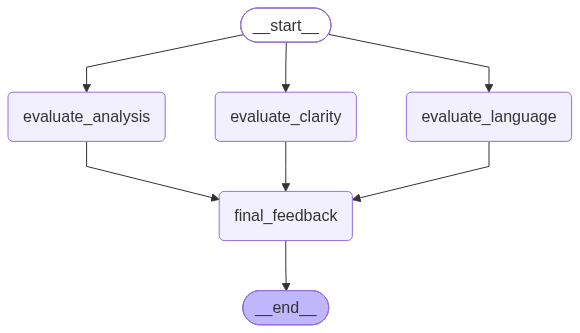

In [51]:
workflow

In [52]:
essay = """Pursuing a PhD represents my commitment to advancing knowledge and contributing meaningful insights to my field. My academic journey has been driven by curiosity, discipline, and a desire to solve complex problems. Through rigorous research, I aim to explore innovative methodologies that challenge conventional thinking and foster interdisciplinary collaboration. I believe scholarship should not only deepen understanding but also serve society. This doctoral path will refine my analytical skills, expand my intellectual horizons, and prepare me to lead impactful research. I am eager to engage with a vibrant academic community and contribute to the evolving landscape of scientific inquiry.
"""

In [58]:
initial_state = {
    'essay': essay
}

result = workflow.invoke(initial_state)
print(result)

c:\Users\itpl59\Desktop\ITPL\Projects\python-examples\langgraph\lang-venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\itpl59\Desktop\ITPL\Projects\python-examples\langgraph\lang-venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\itpl59\Desktop\ITPL\Projects\python-examples\langgraph\lang-venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\itpl59\Desktop\ITPL\Projects\python-examples\langgraph\lang-venv\Lib\site-packages\langchain_g

{'essay': 'Pursuing a PhD represents my commitment to advancing knowledge and contributing meaningful insights to my field. My academic journey has been driven by curiosity, discipline, and a desire to solve complex problems. Through rigorous research, I aim to explore innovative methodologies that challenge conventional thinking and foster interdisciplinary collaboration. I believe scholarship should not only deepen understanding but also serve society. This doctoral path will refine my analytical skills, expand my intellectual horizons, and prepare me to lead impactful research. I am eager to engage with a vibrant academic community and contribute to the evolving landscape of scientific inquiry.\n', 'language_feedback': "The language quality of this essay snippet is excellent. It demonstrates flawless grammar, correct mechanics, and a highly professional, academic tone. The vocabulary choice is sophisticated (e.g., 'interdisciplinary collaboration,' 'intellectual horizons,' 'evolving

In [59]:
print(result['overall_feedback'])
print(result['avg_score'])

[{'type': 'text', 'text': 'Here is a summarized version of the feedback:\n\n---\n\n### **Feedback Summary**\n\n**Strengths:**\n* **Exceptional Language and Style:** The essay is mechanically outstanding, featuring flawless grammar, sophisticated vocabulary, diverse sentence structures, and a polished, professional tone. \n\n**Areas for Improvement:**\n* **Severe Lack of Substance and Specificity:** Despite its stylistic excellence, the essay heavily relies on generic academic buzzwords and platitudes (e.g., *"rigorous research," "innovative methodologies," "advancing knowledge"*). \n* **Vague Vision and Depth:** It lacks analytical depth and clear motivation. Because it fails to identify a specific field, research questions, past academic achievements, or concrete methodologies, the text reads like a generic template applicable to almost any discipline.\n\n**Key Recommendations:**\n1. **Ground the Essay in Specifics:** Name the precise academic discipline, outline specific research que